In [2]:
import sys
path_lock = False
if not path_lock:
    sys.path.append("../")
    path_lock = True
    
import numpy as np
import ffiting as ff

# DSB reference

'Data set generated:'

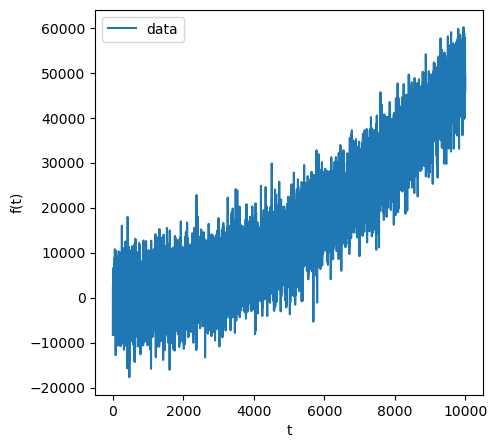

'Training interval data:'

'Expression generated:'

a0 + a1*x + a2*exp(a3*x)

'Coeffs: [-3.03598154e+07  1.74810887e+02  3.03598059e+07 -5.75717660e-06]'

'Metrics:'

Residual SE: 123.826
Mean SE: 15329.720
Linear Div: 852283.603
Standard Div: 14800.530
Standard Err: 148.005
Determination Coeff: 1.000
Correlation Coeff: 1.000
Concordance Coeff: 1.000


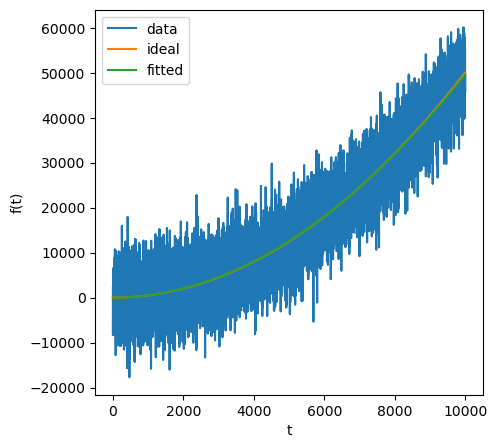

'Testing interval data:'

'Metrics:'

Residual SE: 2901.687
Mean SE: 8418104.732
Linear Div: 24512186.844
Standard Div: 41913.178
Standard Err: 419.153
Determination Coeff: 0.995
Correlation Coeff: 1.000
Concordance Coeff: 0.998


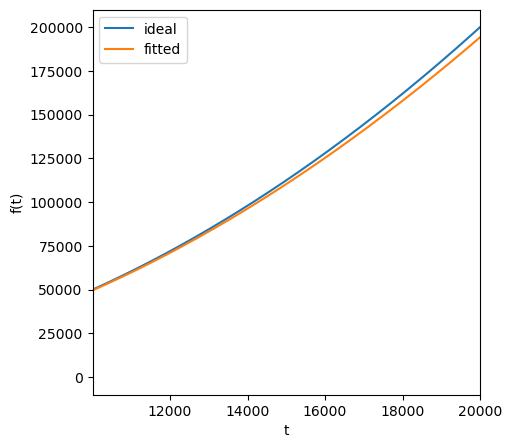

In [3]:
# Exponential
data_x = np.arange(0, 10000)
coeffs_poly = [0, 0, 0.0005]

model_data = ff.Generators.ranked_poly(coeffs_poly)
data_ideal = model_data(data_x)
data_train = ff.apply_noise(data_ideal)

display("Data set generated:")
ff.multi_plot(ff.PlotRequest(data_train, "data"), label_x="t", label_y="f(t)")

model = ff.Models.exponential(ff.FittingModes.DSB)
model.options.echo_on = False
model.options.raise_rank = True
model.options.numeric_optimize = True
model_fitted = model.fit(data_train)
data_fitted = model_fitted(data_x)

display("Training interval data:")
display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")
display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(
    ff.PlotRequest(data_train, "data"),
    ff.PlotRequest(data_ideal, "ideal"),
    ff.PlotRequest(data_fitted, "fitted"),
    label_x="t",
    label_y="f(t)",
)

data_x_predict = np.arange(10001, 20000)
data_ideal_predict = model_data(data_x_predict)
data_predicted = model_fitted(data_x_predict)

display("Testing interval data:")
display("Metrics:")
print(ff.get_metrics(data_predicted, data_ideal_predict))

ff.multi_plot(
    ff.PlotRequest(model_data(np.arange(0, 20000)), "ideal"),
    ff.PlotRequest(model_fitted(np.arange(0, 20000)), "fitted"),
    label_x="t",
    label_y="f(t)",
    xlims=[10001, 20000]
)

'Data set generated:'

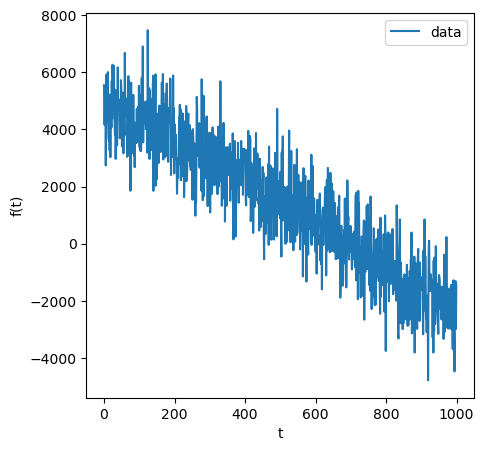

'Training interval data:'

'Expression generated:'

a0*cos(a1*x) + a2*sin(a1*x)

'Coeffs: [ 4.9396367e+03 -7.5518375e-04  8.0519414e+03]'

'Metrics:'

Residual SE: 222.853
Mean SE: 49564.112
Linear Div: 147932.249
Standard Div: 2000.131
Standard Err: 63.250
Determination Coeff: 0.988
Correlation Coeff: 0.999
Concordance Coeff: 0.996


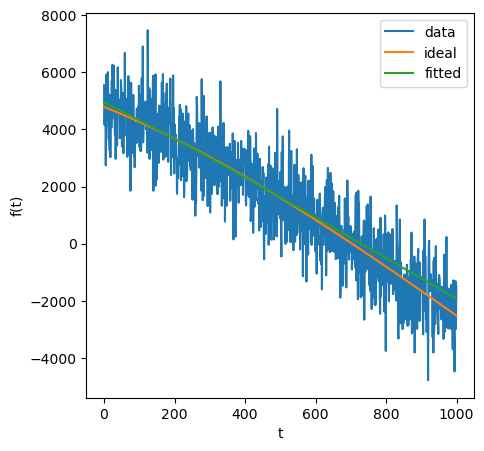

'Testing interval data:'

'Metrics:'

Residual SE: 1819.289
Mean SE: 3303185.605
Linear Div: 1685998.753
Standard Div: 1697.220
Standard Err: 53.698
Determination Coeff: -0.147
Correlation Coeff: 1.000
Concordance Coeff: 0.715


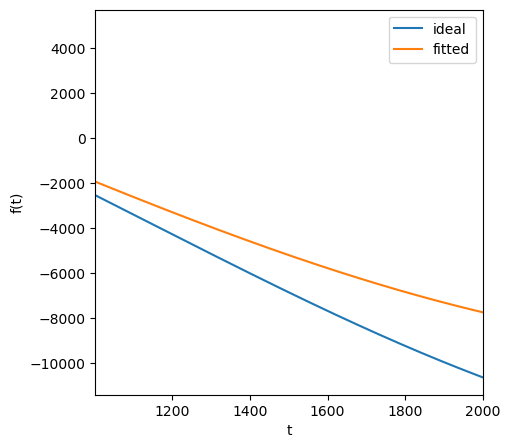

In [22]:
# Transcendental
data_x = np.arange(0, 1000)
coeffs_poly = [4785.5, -4.9093, -0.0034, 10**-6]

model_data = ff.Generators.ranked_poly(coeffs_poly)
data_ideal = model_data(data_x)
data_train = ff.apply_noise(data_ideal, ff.NoiseConfig(0, 1000))

display("Data set generated:")
ff.multi_plot(ff.PlotRequest(data_train, "data"), label_x="t", label_y="f(t)")

model = ff.Models.transcendental(ff.FittingModes.DSB)
model.options.echo_on = False
model.options.raise_rank = True
model.options.numeric_optimize = False
model_fitted = model.fit(data_train)
data_fitted = model_fitted(data_x)

display("Training interval data:")
display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")
display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(
    ff.PlotRequest(data_train, "data"),
    ff.PlotRequest(data_ideal, "ideal"),
    ff.PlotRequest(data_fitted, "fitted"),
    label_x="t",
    label_y="f(t)",
)

data_x_predict = np.arange(1001, 2000)
data_ideal_predict = model_data(data_x_predict)
data_predicted = model_fitted(data_x_predict)

display("Testing interval data:")
display("Metrics:")
print(ff.get_metrics(data_predicted, data_ideal_predict))

ff.multi_plot(
    ff.PlotRequest(model_data(np.arange(0, 2000)), "ideal"),
    ff.PlotRequest(model_fitted(np.arange(0, 2000)), "fitted"),
    label_x="t",
    label_y="f(t)",
    xlims=[1001, 2000]
)

# DSBI smoothing

'Data set generated:'

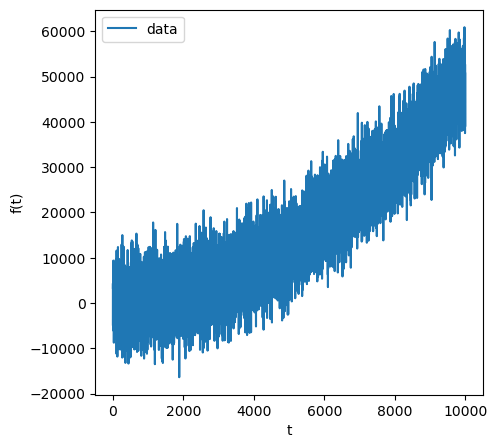

'Training interval data:'

'Coeffs: [-4048433294.9999995, 2012.072142, 4048433294.9999995, -4.970001961e-07]'

'Metrics:'

Residual SE: 31.264
Mean SE: 977.221
Linear Div: 206770.598
Standard Div: 14882.605
Standard Err: 148.826
Determination Coeff: 1.000
Correlation Coeff: 1.000
Concordance Coeff: 1.000


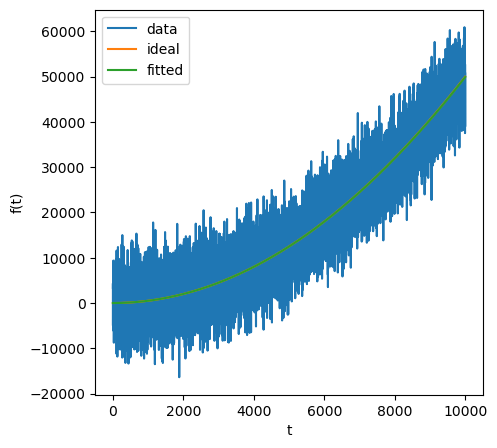

'Testing interval data:'

'Metrics:'

Residual SE: 352.039
Mean SE: 123906.542
Linear Div: 3099146.353
Standard Div: 43290.670
Standard Err: 432.928
Determination Coeff: 1.000
Correlation Coeff: 1.000
Concordance Coeff: 1.000


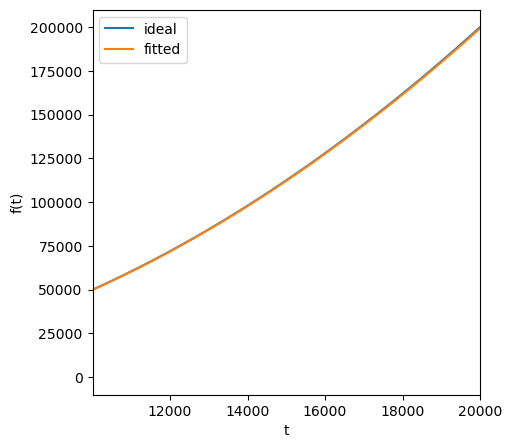

In [ ]:
# Exponential
data_x = np.arange(0, 10000)
coeffs_poly = [0, 0, 0.0005]

model_data = ff.Generators.ranked_poly(coeffs_poly)
data_ideal = model_data(data_x)
data_train = ff.apply_noise(data_ideal)

display("Data set generated:")
ff.multi_plot(ff.PlotRequest(data_train, "data"), label_x="t", label_y="f(t)")

# Using maple coeffs
maple_coeffs = [-4.048433295*10**9, 2012.072142, 4.048433295*10**9,  -4.970001961*10**(-7)]
def model_maple(x: float) -> float:
    return maple_coeffs[0] + maple_coeffs[1] * x + maple_coeffs[2] * np.exp(maple_coeffs[3] * x)

data_fitted = np.zeros(data_x.size)
for i in np.arange(data_x.size):
    data_fitted[i] = model_maple(data_x[i])

display("Training interval data:")
display(f"Coeffs: {maple_coeffs}")
display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(
    ff.PlotRequest(data_train, "data"),
    ff.PlotRequest(data_ideal, "ideal"),
    ff.PlotRequest(data_fitted, "fitted"),
    label_x="t",
    label_y="f(t)",
)

data_x_predict = np.arange(10001, 20000)
data_ideal_predict = model_data(data_x_predict)
data_predicted = model_maple(data_x_predict)

display("Testing interval data:")
display("Metrics:")
print(ff.get_metrics(data_predicted, data_ideal_predict))

ff.multi_plot(
    ff.PlotRequest(model_data(np.arange(0, 20000)), "ideal"),
    ff.PlotRequest(model_maple(np.arange(0, 20000)), "fitted"),
    label_x="t",
    label_y="f(t)",
    xlims=[10001, 20000]
)

'Data set generated:'

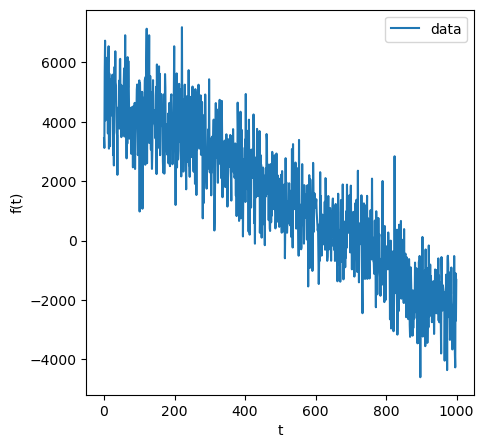

'Training interval data:'

'Expression generated:'

a0*cos(a1*x) + a2*sin(a1*x)

'Coeffs: [ 4.9028789e+03 -8.1394380e-04  7.1594795e+03]'

'Metrics:'

Residual SE: 264.732
Mean SE: 69942.772
Linear Div: 176497.875
Standard Div: 1968.204
Standard Err: 62.240
Determination Coeff: 0.982
Correlation Coeff: 0.999
Concordance Coeff: 0.995


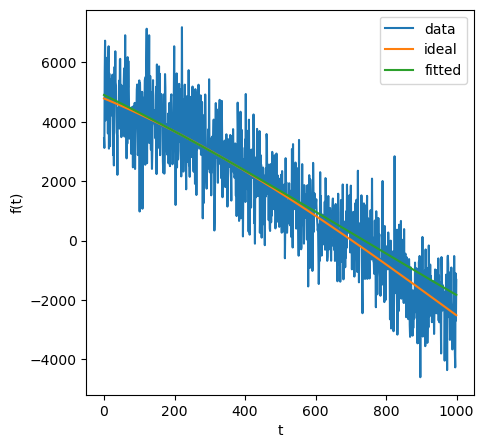

'Testing interval data:'

'Metrics:'

Residual SE: 1998.442
Mean SE: 3985775.472
Linear Div: 1852877.138
Standard Div: 1634.630
Standard Err: 51.717
Determination Coeff: -0.492
Correlation Coeff: 0.999
Concordance Coeff: 0.670


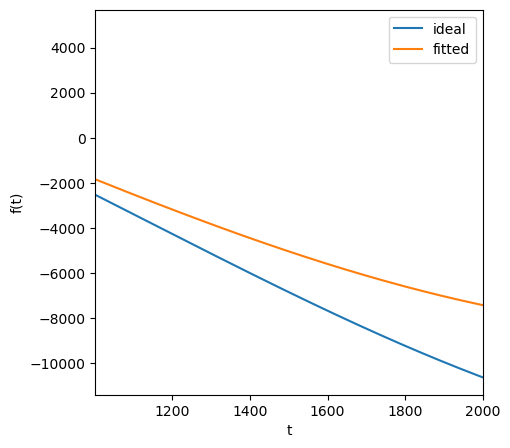

In [31]:
# Transcendental
data_x = np.arange(0, 1000)
coeffs_poly = [4785.5, -4.9093, -0.0034, 10**-6]

model_data = np.poly1d(coeffs_poly[::-1])
data_ideal = model_data(data_x)
data_train = ff.apply_noise(data_ideal, ff.NoiseConfig(0, 1000))

display("Data set generated:")
ff.multi_plot(ff.PlotRequest(data_train, "data"), label_x="t", label_y="f(t)")

model = ff.Models.transcendental(ff.FittingModes.DSBI)
model.options.echo_on = False
model.options.raise_rank = True
model.options.numeric_optimize = False
model_fitted = model.fit(data_train)
data_fitted = model_fitted(data_x)

display("Training interval data:")
display("Expression generated:", model.expr_sp)
display(f"Coeffs: {model_fitted.coeffs}")
display("Metrics:")
print(ff.get_metrics(data_fitted, data_ideal))

ff.multi_plot(
    ff.PlotRequest(data_train, "data"),
    ff.PlotRequest(data_ideal, "ideal"),
    ff.PlotRequest(data_fitted, "fitted"),
    label_x="t",
    label_y="f(t)",
)

data_x_predict = np.arange(1001, 2000)
data_ideal_predict = model_data(data_x_predict)
data_predicted = model_fitted(data_x_predict)

display("Testing interval data:")
display("Metrics:")
print(ff.get_metrics(data_predicted, data_ideal_predict))

ff.multi_plot(
    ff.PlotRequest(model_data(np.arange(0, 2000)), "ideal"),
    ff.PlotRequest(model_fitted(np.arange(0, 2000)), "fitted"),
    label_x="t",
    label_y="f(t)",
    xlims=[1001, 2000]
)